<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/>

# Time Series with Pandas
---
<small>© COPYRIGHT 2023 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

## Content

### Overview

- How do you handle time series data in `pandas`?
    - Read the csv with `pandas` and check data types with `dtypes`
    - Use `pd.to_datetime()` to convert date column type and set as index using `.set_index()`
    - Challenge: apply some `methods` to explore the time series data, such as `info()` and  `describe()`
    - Handling missing dates in a `datetime` index with `.asfreq()`
- How do you visualise a time series?
    - Plot a time series with a `datetime` index using `.plot()`
- How do you index and filter a time series?
    - Challenge: Slicing and subsetting a time series with a `datetime` index
- How can you change the frequency of your time series data?
    - Use the `pandas` function `.asfreq()` to either upsample or downsample time series data
        - Challenge: Plot and compare the year end and start frequencies of a daily time series using `.asfreq()` and `.plot()`
    - Resample a time series in `pandas` with the `.resample()` method
        - Challenge: Plot the yearly average of a daily time series using `.resample()` and `.plot`
    - Perform a rolling average on time series data with `.rolling()`
        - Challenge: Visualise a yearly rolling average using `.rolling(window=...).mean()` on daily data


### Introductions

#### Purpose: What is the aim of the content?

This workshop aims to build an understanding of what is a time series and the basics of how to handle time series data in Python.

By describing the key features of `pandas` that support time series analysis and performing basic operations on time series such as slicing, indexing, and resampling, you will start to feel more comfortable to begin exploring and manipulating time series data.

#### Objectives: What will I learn?

* Describe the key features of pandas which support time series analysis, especially indexing and filtering
* Explore a time series dataset with pandas
* Use the main Python libraries for time series analysis to visualize and prepare the data for further analysis.
* Perform basic operations on time series such as slicing, indexing, and resampling.

#### Process: How will I learn this content?

##### Outline

- Menti quiz
- Group discussions
- Coding demos
- Coding challenges

#### Applications: Why study time series in Pandas?

Studying time series is important for anyone who deals with time-based data, as it enables you to understand and analyze the patterns and trends that exist over time. Time series analysis has numerous practical applications, such as forecasting future values, identifying trends and seasonality, and detecting anomalies in data.

`Pandas` provides powerful tools and functionalities for handling and analyzing time series data, including indexing, filtering, resampling, and time-based visualization, making it a widely used and popular library for time series analysis.

---

### How do you handle time series data in `pandas`?

In order for `pandas` to treat a series of data points as a time series, the **index** of the `dataframe` (or `series`) needs to be a pandas `datetime` object.

Import `pandas`

In [1]:
import pandas as pd

Load in your data in the usual way (such as with `pd.read_csv('your_file.csv')`).

In [2]:
auck = pd.read_csv('AucklandTemperatureData.csv')

Your data should contain at least one column indicating the time and one column containing the values of the time series.

Check the data types and notice how the date has been loaded as an `object` (i.e. a string)

In [3]:
display(auck.info())
auck.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 19710 entries, 0 to 19709
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19710 non-null  str    
 1   temperature  19710 non-null  float64
dtypes: float64(1), str(1)
memory usage: 308.1 KB


None

,date,temperature
0,2001-08-24,13.8
1,2014-01-24,19.4
2,1971-01-06,23.4


Use `pd.to_datetime()` to convert to date column type

In [4]:
auck['date'] = pd.to_datetime(auck['date'])
auck.dtypes

date           datetime64[us]
temperature           float64
dtype: object

Make the new `datetime` time column the **index** of the `dataframe` with `.set_index()`.

In [5]:
auck = auck.set_index('date')
auck.head()

,temperature
date,
2001-08-24,13.8
2014-01-24,19.4
1971-01-06,23.4
1990-03-04,21.4
2008-09-16,13.3


Your data should be ordered sequentially starting with the earliest to the latest date.

Use `.sort_index()` with `ascending=True` to sort your data in ascending order.

In [6]:
auck = auck.sort_index(ascending=True)
auck.head(3)

,temperature
date,
1966-01-01,18.1
1966-01-02,20.5
1966-01-03,20.3


In [7]:
auck.tail()

,temperature
date,
2019-12-27,18.9
2019-12-28,18.2
2019-12-29,17.5
2019-12-30,18.6
2019-12-31,20.3


In [8]:
#plt.style.available

### How do you visualise a time series?

Visualising a time series stored in a `dataframe` with a `datetime` index is as simple as calling the `.plot()` method. This is extremely powerful if you have more than one time series (i.e. more than one column with values), for example the prices of different stocks over a set period of time.

#### Plot a time series with a `datetime` index using `.plot()`

Set plotting configurations

<Axes: xlabel='date'>

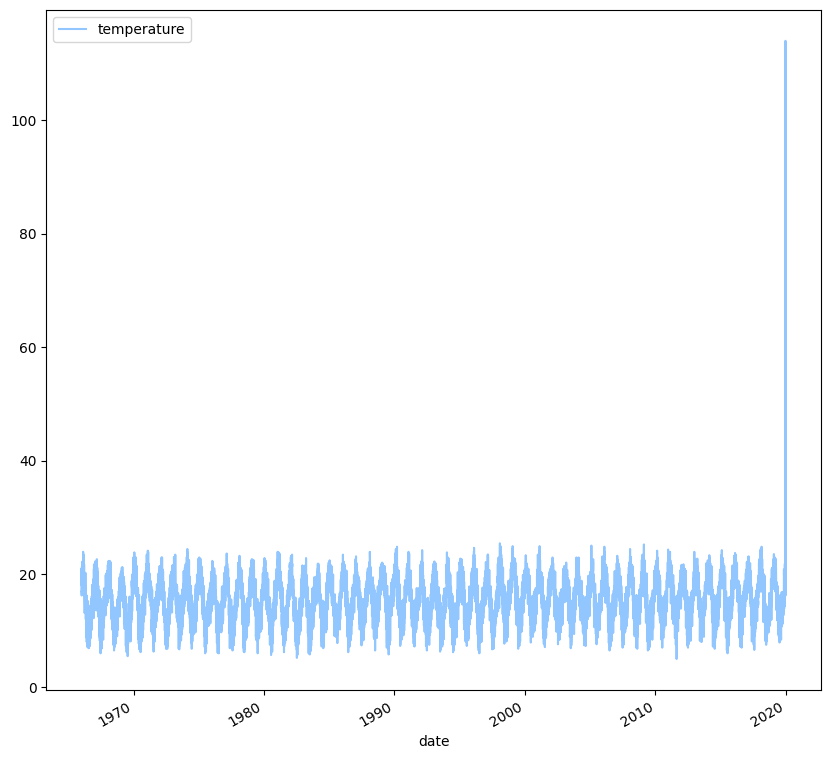

In [9]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')
plt.rcParams['figure.figsize'] = (10,10)
auck.plot()

### How do you index and filter a time series?

With a `datetime` index, indexing and slicing become quite intuitive. For example, to limit your time series to the decade of the 90s you can simply use `df["1990":"2000"]` (for older versions of pandas) or `df.loc["1990":"2000"]` (for newer versions).

`datetime` indices have a lot of properties that are date specific. For instance you can easily access data such as the `.year`, `.month`, or `.day`, as well as more sophisticated information such as `.day_of_week`, `.quarter`, and `.is_leap_year`.

#### Challenge: Slicing and Subsetting a time series

Explore the power of `datetime` indices by trying to plot the following:

* The daily temperatures for the year 2000
* The daily temperatures for the decade starting in 2000
* Stretch: The temperatures on Mondays (hint: use `auckland.index.day_name() == 'Monday'` as your filter)

<Axes: xlabel='date'>

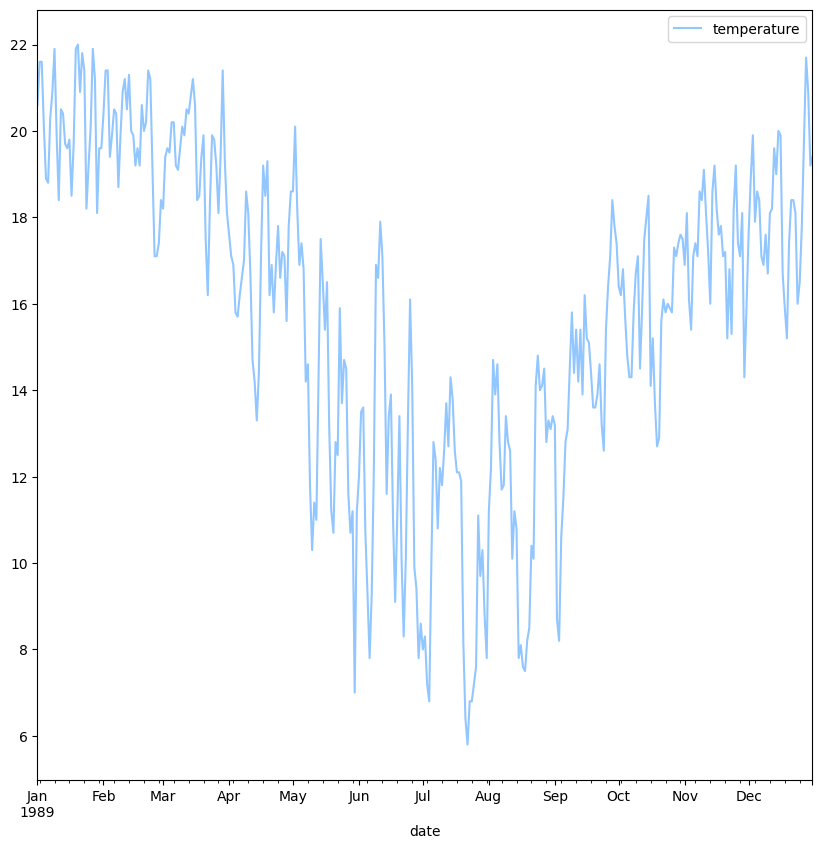

In [10]:
auck.loc['1989'].plot()

<Axes: xlabel='date'>

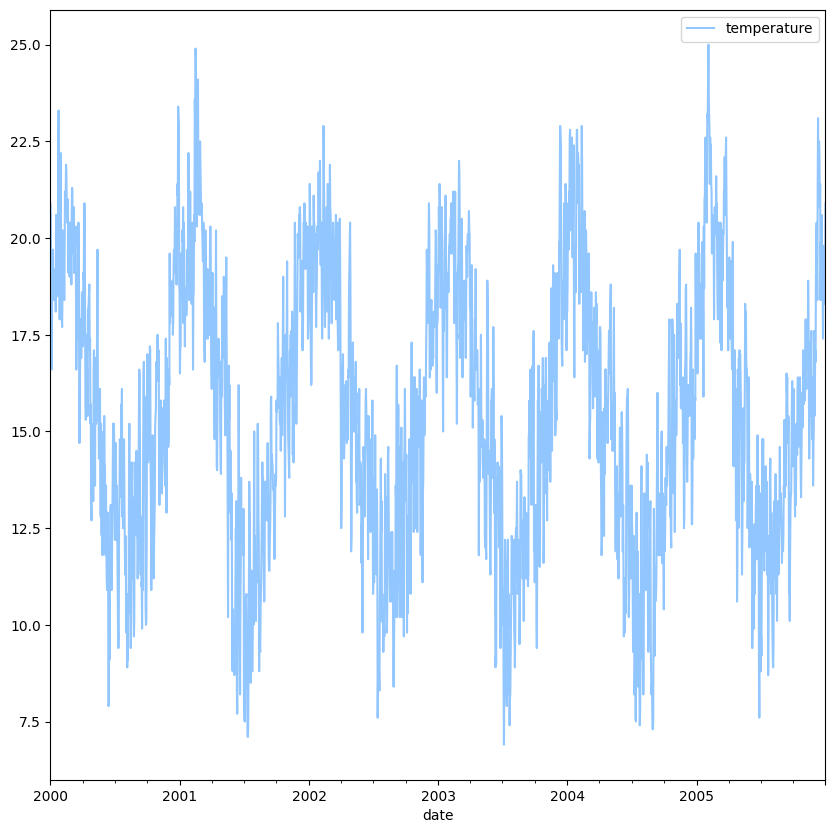

In [11]:
auck.loc['2000':'2005'].plot()

<Axes: xlabel='date'>

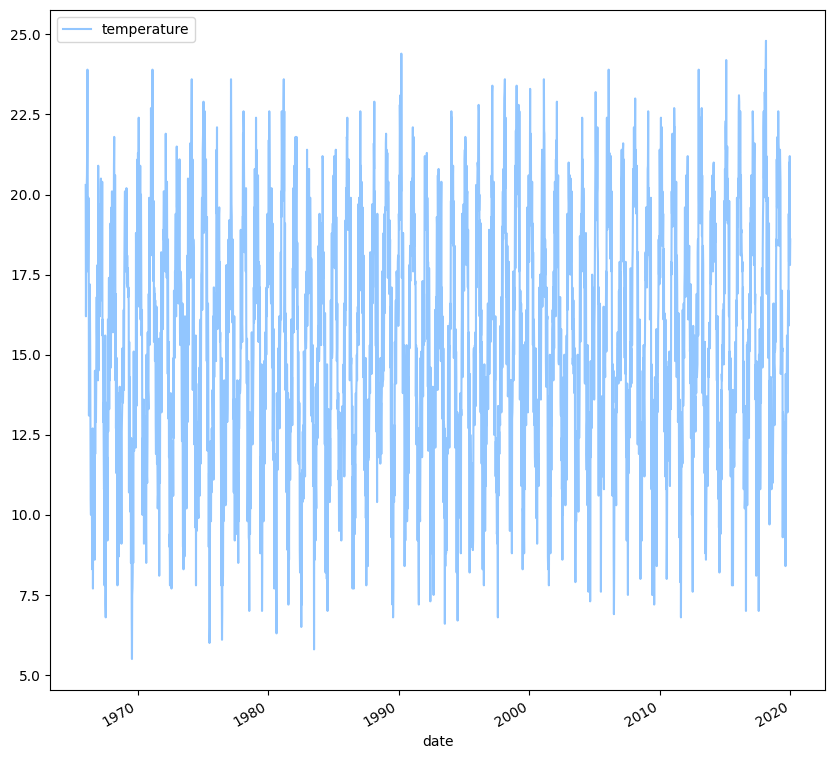

In [12]:
auck[auck.index.day_name() == 'Monday'].plot()

TEACHER NOTE

State that you can apply the same methods to a time series that you are familiar with in `Pandas` for exploring dataframes.

#### Challenge: apply some known `methods` to explore the time series data, such as `info()` and  `describe()`

Explore the Auckland average temperature data and answer the following questions, noting down any observations:

- Are there any missing values in the dataset? How can you be sure? (*Note: datetime indices accept unevenly spaced data.*)

- Are there any outliers in our temperature values?

SOLUTION (NOTES)

In [13]:
auck.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 19710 entries, 1966-01-01 to 2019-12-31
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  19710 non-null  float64
dtypes: float64(1)
memory usage: 824.0 KB


In [14]:
auck.describe()

,temperature
count,19710.000000
mean,15.411588
std,3.810751
min,5.000000
25%,12.600000
50%,15.300000
75%,18.400000
max,114.000000


In [15]:
auck.index.max() - auck.index.min()

Timedelta('19722 days 00:00:00')

Observations:

- Since datetime indices accept unevenly spaced data, we can't rely on null / non-null counts.
- There are 19,700 data points from 1966-01-01 to 2019-12-31, however there are 19,723 days between these dates inclusive of start and end date therefore there seems to be missing temperature values.
- Mean and median are very similar, however, the max value seems VERY large and since these temperatures are measured in degrees celcius, it is an impossible value, in fact the world's highest recorded temperature was 56.7°C (134°F).

### Outliers  in time series data

Outliers are data points that are significantly different from the rest of the data. Sometimes these are errors e.g. caused by poor data entry or failed measurements. Other times they could be true values e.g. caused by unusual events or changes in the environment.

Some examples of where outlier values can be of interest,
- **Fraudulent behavior:** an abnormal spike in credit card transactions or a sudden change in purchase patterns may indicate fraudulent activity.

- **Network intrusion:** a sudden spike in traffic from an unknown IP address may indicate a potential attack on your network system.

- **Equipment failure:** abnormal patterns in sensor data could be used to identify equipment failures.

- **Health issues:** sudden changes in heart rate or blood pressure may indicate a health issue that needs attention.

We refer to these outliers as anomalies and there is a range of time series techniques for anomaly detection. Therefore, it is good to investigate your outliers to understand the underlying causes or implications before making a decision on how to handle them.

Let's take a take our Auckland temperature data example.

A quick google search tells us that the highest recorded temperatures in New Zealand was 42.4 °C

Therefore, let's filter our data for temperatures outside of this range.

In [16]:
auck[auck['temperature'] > 42.4]

,temperature
date,
2019-12-20,114.0


There is only one value and it is significantly greater than the maximum recorded temperature. This is clearly an erroneous value as even the world's highest recorded temperature was much less, at 56.7 °C.

So how shall we handle it?

#### Challenge: explore different ways to handle an outlier value in a time series

- Look at the results of `.describe()` with the outlier value excluded, is there an appropriate statistic we could use to replace our outlier value with?
    - hint: you can use `auckland.drop("2019-12-20")` to drop the outlier


- By filtering the data look at the values surrounding the outlier and discuss what ways you could use these values to replace our outlier value. Discuss whether or not these ways are appropriate and why.
    - hint: you can use `auckland.loc[:]` with a date range to filter the data


- Thinking about the nature of our data and how weather temperatures change throughout the year, would looking at the mean value over December months be a good option?
    - hint: you can use `auckland.index.month == 12` to filter for the 12th month of the year


- Stretch: Decide with your group on which of the options discussed are most suitable and apply this method to replace the outlier value.

SOLUTION (NOTES)

Observations:

- The mean or median could be good values to use, however, we expect temperature to be seasonal, therefore the overall mean or median may not be the best statistic to use to replace our outlier value with.


- The values surrounding the outlier look higher than the overall mean and median, looking at the dates, this is the month of December which is summer time in Auckland so this makes sense. Therefore, it may be better to use the previous or following value to replace our outlier value with.


- The mean value across the months of December seems like a better option than using the overall mean due to seasonality.


- A preferred (and simple) approach is to forward fill or back fill the value with the temperature on the adjacent day, as we would expect temperatures to not vary much day to day.

In [17]:
auck.drop('2019-12-20').describe()

,temperature
count,19709.000000
mean,15.406586
std,3.745578
min,5.000000
25%,12.600000
50%,15.300000
75%,18.400000
max,25.400000


In [18]:
auck.loc['2019-12-18': '2019-12-22']

,temperature
date,
2019-12-18,17.1
2019-12-19,18.1
2019-12-20,114.0
2019-12-21,16.7
2019-12-22,16.2


In [19]:
auck[auck.index.month == 12].mean()

temperature    18.33859
dtype: float64

Some popular methods to replace outlier or missing values in a time series are,

- **Forward fill:** Use the previous value in the series.

- **Backward fill:** Use the next value in the series.

- **Interpolation:** Estimate the missing values based on the available data (there are many different methods for interpolation).

These are just a few ways and you should choose a method that makes sense to you depending on your specific data and analysis.

Let's replace the outlier value with the previous value in the series,

In [20]:
auck.loc['2019-12-20'] = auck.loc['2019-12-19']

Check the result,

In [21]:
auck.loc['2019-12-18': '2019-12-22']

,temperature
date,
2019-12-18,17.1
2019-12-19,18.1
2019-12-20,18.1
2019-12-21,16.7
2019-12-22,16.2


#### Handling missing dates in a `datetime` index with `.asfreq()`

`datetime` indices accept unevenly spaced data, therefore missing dates will not come through as rows and therefore will not be picked up as `NaN`.

In order to be sure of where we may have missing dates in our index, we can apply `.asfreq()` with the appropriate offset alias (frequency of dates).

In [22]:
auck = auck.asfreq('D')

Since we have daily data we will apply a daily `'D'` frequency to our dataset, this will fill in any missing dates from the index with a corresponding `NaN` value.

In [23]:
auck.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 19723 entries, 1966-01-01 to 2019-12-31
Freq: D
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  19710 non-null  float64
dtypes: float64(1)
memory usage: 308.2 KB


See a range of other available offset aliases in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases.

The shape of the data is now 19,723 and `NaN`s are detected, therefore we have missing dates in our index.

Let's take a look at which dates are missing, by filtering for where we have `NaNs`

In [24]:
auck[auck['temperature'].isna()]

,temperature
date,
1966-09-13,NaN
1969-02-27,NaN
1971-04-11,NaN
1974-04-12,NaN
1974-05-07,NaN
1974-10-25,NaN
1977-07-02,NaN
1980-02-23,NaN
1981-03-04,NaN


Let's see which years had missing values, we can use `.year` on the index and run a `.value_counts()` to see how many missing values we had for each year.

In [25]:
auck[auck['temperature'].isna()].index.year.value_counts()

date
1974    3
1995    2
1966    1
1969    1
1971    1
1977    1
1980    1
1981    1
1987    1
1992    1
Name: count, dtype: int64

Remember our data goes from `1966-01-01` to `2019-12-31`. It seems like we only have missing values from before the 2000s, perhaps the systems improved or a process is in place to handle missing values post 2000s.

Some popular ways to replace missing values for a time series in `pandas`:

- **Forward fill:** The `fillna()` function can be used to forward fill missing values with the previous value in the series, set `method='ffill'`.

- **Backward fill:** Similar to forward fill, the `fillna()` function can also be used to backward fill missing values with the next value in the series, set `method='bfill'`.

- **Interpolation:** The `interpolate()` function can be used to estimate the missing values based on the available data ([see documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html) for the different methods).

Let's forward fill the missing values in the time series,

In [30]:
auck['temperature'] = auck['temperature'].ffill()

In [31]:
auck.isna().sum()

temperature    0
dtype: int64

TEACHER NOTES

State that it is important to not have any missing dates in your index for most time series forecasting models, including ARIMA.

### How can you change the frequency of your time series data?

We may wish to change the granularity of our data, say we are interested in yearly values instead of the monthly values.

- The following functions are available to help us change the frequency of our data:

    - `.asfreq()`
    - `.resample()`
    - `.rolling()`

We can specify the frequency we want as follows:

```python
df.asfreq('insert offset alias')
```

Where, `'D'` = daily, `'W'` = weekly, `'Y'` = yearly etc. See all [offset aliases in the doc](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases).


#### Downsampling
For example, if you have daily values which you want to convert to monthly, thus decreasing the total number of data points (downsampling) you can use `.asfreq('M')` which takes the value on the final day of each each month as the downsampled value.

#### Upsampling
For upsampling a time series, e.g. converting from weekly to daily values, the reindexed series will have `NaN`s unless we set the argument `method` to back filling or forward filling, or we set the argument `fill_value` to a value the function can use to fill in the missing values.

#### Challenge: Plot and compare the year end and start frequencies of a daily time series using `.asfreq()` and `.plot()`

Note down any observations.

Hint: You can use `matplotlib`'s plotting method to to plot on the same graph

```python
from matplotlib import pyplot as plt

plt.plot(df1)
plt.plot(df2)
```


[See documentation for available time offsets](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases)

SOLUTION (NOTES)

Observations:

- In the decade of 80s, the year start temperature was mostly higher than the year end temperatures, whereas in the 90s, the year end temperature were mostly higher than the year start temperatures.

#### Resample a time series in `pandas` with the `.resample()` method

`.resample()` allows you to specify a time interval (for example converting daily observations to weekly or yearly) as well as aggregation methods like min, max, mean, median, etc. (same idea as `.groupby()`).

This can come in particularly handy if you have unevenly spaced data.

#### Challenge: Plot the yearly average of a daily time series using `.resample()` and `.plot`

Hint: you will need to provide:

1. A new frequency or time offset (see [documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases) for some common offset aliases).
2. An aggregator, just like when using `.groupby()`.

In [ ]:
#auck['temperature'] = auck['temperature'].astype(float)

<Axes: xlabel='date'>

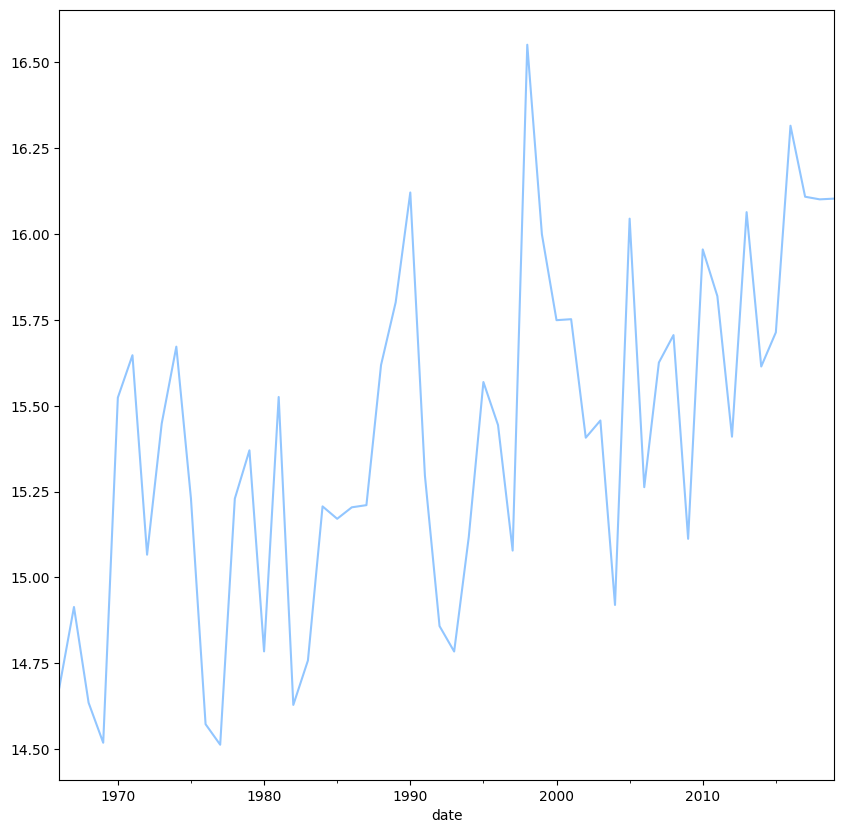

In [36]:
auck.resample('1YE')['temperature'].mean().plot()

#### Perform a rolling average on time series data with `.rolling()`

Rolling averages, or moving averages, are a popular technique that reduces the randomness and increases the relative importance of the signal components of our series.

The most common version entails a "tail-rolling" technique where the average is taken over a window period - a period is a pre-specified time interval occurring just before the present time `t`.

This will smooth the series as the fluctuations within a window are substituted by their average.

Like resampling, you'll need to specify a window with the `.rolling(window=...)` method, followed by an aggregator (usually `.mean()`).

#### Challenge: Visualise a yearly rolling average using `.rolling(window=...).mean()` on daily data

Hint: Since our data is daily, a window of 365 time steps is a year.

<Axes: xlabel='date'>

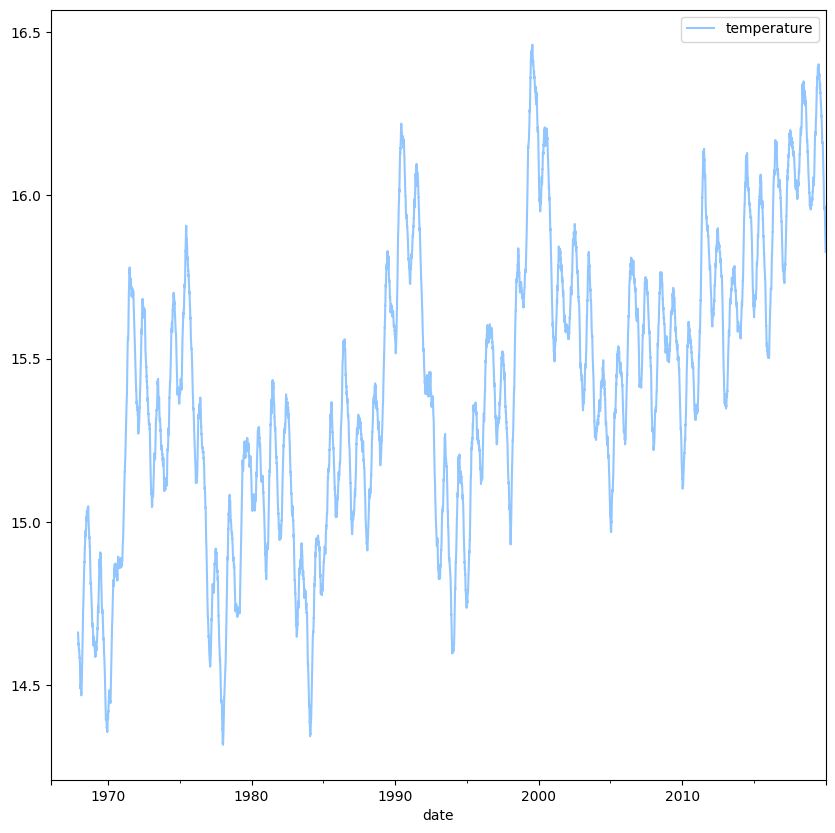

In [44]:
auck.rolling(window = 700).mean().plot()

discussion on smoothing

### Review: Time Series Pandas

#### What did we learn?

* Describe the key features of pandas which support time series analysis, especially indexing and filtering
* Explore a time series dataset with pandas
* Use the main Python libraries for time series analysis to visualize and prepare the data for further analysis.
* Perform basic operations on time series such as slicing, indexing, and resampling.

---

# END